# BFS distance metric — impact on waypoint selection & ordering

`bfs_distance_map` counts **1 per step in all 8 directions**, so a diagonal move (physically
√2 ≈ 1.414 cells) is charged the same as a cardinal move. This under-measures diagonally-reached
distances by up to √2×.

That distance is used two ways:
1. **`greedy_set_cover`** — as a *magnitude* in the travel-cost penalty
   `score = gain / (1 + γ · bfs_dist / normaliser)`. A biased magnitude can change *which*
   candidates are selected.
2. **`nearest_neighbor_order`** — to decide the TSP *visit order*.

For pure ordering a consistent bias mostly cancels; as a magnitude in a formula it may not.
**This notebook quantifies whether replacing uniform-cost BFS with a √2-weighted Dijkstra
(the geometrically-correct metric) actually changes the plan, and by how much** — to decide
whether the approximation is negligible or worth fixing.

Method: monkeypatch `explore_costmap_map.bfs_distance_map` (every internal caller goes through
that one symbol), run the **real** `plan_waypoints` twice per case — once uniform, once weighted —
and diff the outputs across a sweep of γ, maps, and robot start positions.

> The weighted Dijkstra used as ground truth is validated against `scipy.sparse.csgraph.dijkstra`
> in the setup cell before it is trusted.

In [16]:
import sys, heapq, itertools
from pathlib import Path

import numpy as np
import yaml
from PIL import Image
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / ".git").exists() and not (ROOT / "docker-compose.yml").is_file():
    ROOT = ROOT.parent
ASSETS = ROOT / "assets"
sys.path.insert(0, str(ROOT / "ros2_ws/src/navigation/exploration"))

import exploration.explore_costmap_map as ecm
from exploration.explore_costmap_map import build_map_data, world_to_pixel

print("repo root:", ROOT)

repo root: /home/idlab332/workspace/ros_ws/src/TRAVIS


## Ground-truth metric: √2-weighted grid Dijkstra (validated)

Same call signature as `bfs_distance_map(navigable_mask, start_col, start_row) -> (H,W) float`,
so it can be dropped in by monkeypatch. Diagonal edges cost √2, cardinal cost 1. Because edges
are weighted, first-visit is no longer shortest — this needs a priority queue + relaxation
(true Dijkstra), not BFS. Validated against SciPy below.

In [17]:
from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse.csgraph import dijkstra as _sp_dijkstra

SQRT2 = 2 ** 0.5
_NEI = [(-1,-1,SQRT2),(-1,0,1.0),(-1,1,SQRT2),(0,-1,1.0),
        (0,1,1.0),(1,-1,SQRT2),(1,0,1.0),(1,1,SQRT2)]

# Cache the sparse grid-graph + node index per mask so repeated source queries on the same
# map are fast C-level scipy calls. Keyed by a content signature (not id()): Python reuses
# id() for garbage-collected arrays, which would return a stale graph for a different mask.
_graph_cache = {}


def _mask_key(mask):
    return (mask.shape, hash(mask.tobytes()))


def _build_graph(mask):
    H, W = mask.shape
    idx = -np.ones((H, W), int)
    ys, xs = np.where(mask)
    idx[ys, xs] = np.arange(len(ys))
    I, J, V = [], [], []
    for dr, dc, w in _NEI:  # vectorised: link each navigable cell to its navigable neighbour
        r0, r1 = max(0, -dr), H - max(0, dr)
        c0, c1 = max(0, -dc), W - max(0, dc)
        both = mask[r0:r1, c0:c1] & mask[r0+dr:r1+dr, c0+dc:c1+dc]
        si = idx[r0:r1, c0:c1][both]
        di = idx[r0+dr:r1+dr, c0+dc:c1+dc][both]
        I.append(si); J.append(di); V.append(np.full(si.size, w))
    G = csr_matrix((np.concatenate(V), (np.concatenate(I), np.concatenate(J))),
                   shape=(len(ys), len(ys)))
    return G, idx


def dijkstra_weighted(navigable_mask, start_col, start_row):
    """Drop-in for bfs_distance_map with diagonal=√2 edge weights (scipy-backed, cached).

    Same signature/return as bfs_distance_map: (H,W) float distances, inf where unreachable.
    """
    H, W = navigable_mask.shape
    dist = np.full((H, W), np.inf)
    if not (0 <= start_row < H and 0 <= start_col < W and navigable_mask[start_row, start_col]):
        return dist
    key = _mask_key(navigable_mask)
    if key not in _graph_cache:
        _graph_cache[key] = _build_graph(navigable_mask)
    G, idx = _graph_cache[key]
    dmap = _sp_dijkstra(G, indices=int(idx[start_row, start_col]))
    ys, xs = np.where(navigable_mask)
    dist[ys, xs] = dmap
    return dist


# --- validate against an independent scipy graph build on random maps ---
def _scipy_ref(mask, sc, sr):
    H, W = mask.shape
    idx = lambda r, c: r * W + c
    g = lil_matrix((H * W, H * W))
    for r in range(H):
        for c in range(W):
            if not mask[r, c]:
                continue
            for dr, dc, w in _NEI:
                nr, nc = r + dr, c + dc
                if 0 <= nr < H and 0 <= nc < W and mask[nr, nc]:
                    g[idx(r, c), idx(nr, nc)] = w
    return _sp_dijkstra(g.tocsr(), indices=idx(sr, sc)).reshape(H, W)

_rng = np.random.default_rng(3); _bad = 0
for _ in range(60):
    H = int(_rng.integers(4, 16)); W = int(_rng.integers(4, 16))
    m = _rng.random((H, W)) < _rng.uniform(0.5, 0.95)
    sr, sc = int(_rng.integers(0, H)), int(_rng.integers(0, W))
    if not m[sr, sc]:
        continue
    a = dijkstra_weighted(m, sc, sr); b = _scipy_ref(m, sc, sr)
    if not np.allclose(np.nan_to_num(a, posinf=-1), np.nan_to_num(b, posinf=-1), atol=1e-9):
        _bad += 1
print("weighted-Dijkstra vs scipy mismatches:", _bad, "(must be 0 to trust the study)")

weighted-Dijkstra vs scipy mismatches: 0 (must be 0 to trust the study)


## Cases

Same real maps as the candidate-strategy study (`lab_ghent`, `lab_05`), plus a **45°
diagonal-corridor** synthetic where the uniform-cost error is maximal (every optimal step is
diagonal) — the worst case for the approximation. Each map is swept over several robot start
positions and a range of γ (travel_cost_weight).

In [18]:
def load_real(name):
    d = ASSETS / name
    yml = yaml.safe_load(open(d / "map.yaml"))
    arr = np.array(Image.open(d / "map.pgm"), dtype=np.uint8)
    res = float(yml["resolution"])
    md = build_map_data(1.0 - arr / 255.0, res,
                        float(yml["origin"][0]), float(yml["origin"][1]),
                        inflation_radius_m=0.9)
    return md


def make_diagonal_map(n=200, width=9, res=0.05):
    """A thick 45° corridor: optimal paths are all-diagonal → maximal uniform-cost error."""
    free = np.zeros((n, n), bool)
    for i in range(n):
        lo, hi = max(0, i - width // 2), min(n, i + width // 2 + 1)
        free[i, lo:hi] = True
    occ = ~free
    p_occ = occ.astype(float)          # free=0, occupied=1
    return build_map_data(p_occ, res, 0.0, 0.0, inflation_radius_m=0.10)


def robot_starts(md, k):
    """k navigable world positions spread across the map (deterministic)."""
    rows, cols = np.where(md.navigable_mask)
    if len(rows) == 0:
        return []
    H = md.pgm_array.shape[0]
    picks = np.linspace(0, len(rows) - 1, k).astype(int)
    out = []
    for p in picks:
        c, r = int(cols[p]), int(rows[p])
        x = md.origin_x + c * md.resolution
        y = md.origin_y + (H - 1 - r) * md.resolution
        out.append((x, y))
    return out


CASE_MAPS = {
    "lab_ghent": load_real("lab_ghent"),
    "lab_05": load_real("lab_05"),
    "diagonal_corridor": make_diagonal_map(),
}
GAMMAS = [0.0, 0.5, 1.0, 2.0, 5.0]

# Robot starts per map. NOTE: each plan_waypoints call is ~5–9 s (360-ray visibility in pure
# Python dominates — not the distance metric), and we run 2 plans × N_starts × len(GAMMAS) per
# map. So STARTS_PER_MAP is the runtime knob:
#   4  → exhaustive (~15+ min, run it yourself and let it finish)
#   1–2 → quick look while iterating.
STARTS_PER_MAP = 4
STARTS = {name: robot_starts(md, STARTS_PER_MAP) for name, md in CASE_MAPS.items()}
for name, md in CASE_MAPS.items():
    print(f"{name}: {md.pgm_array.shape}, navigable={int(md.navigable_mask.sum())}, "
          f"starts={len(STARTS[name])}")
n_plans = 2 * len(GAMMAS) * sum(len(s) for s in STARTS.values())
print(f"\ntotal plan_waypoints calls: {n_plans}  (≈{n_plans * 7 / 60:.0f} min at ~7s/plan)")

lab_ghent: (280, 649), navigable=27349, starts=4
lab_05: (226, 362), navigable=13731, starts=4
diagonal_corridor: (200, 200), navigable=994, starts=4

total plan_waypoints calls: 120  (≈14 min at ~7s/plan)


## A/B harness + metrics

For each (map, start, γ) we run `plan_waypoints` with the uniform metric and with the weighted
metric (monkeypatched), then compute:

- **selection Jaccard** — `|A∩B|/|A∪B|` of the selected `(col,row)` sets (1.0 = identical choice)
- **first-waypoint match** — does the robot's *next* goal change? (most operationally relevant)
- **order agreement (Kendall τ)** — over waypoints common to both plans
- **true-tour-length Δ%** — both visit orders scored under the *weighted* (true) metric, so we
  see whether the uniform plan actually costs more to drive

In [19]:
from contextlib import contextmanager

@contextmanager
def patched_metric(func):
    """Temporarily replace the module-level bfs_distance_map that every planner call uses."""
    orig = ecm.bfs_distance_map
    ecm.bfs_distance_map = func
    try:
        yield
    finally:
        ecm.bfs_distance_map = orig


def _cfg(gamma):
    return {"max_detection_range": 6.0, "fov_horizontal": 87.0,
            "observation_rotation_increment": 30.0, "sampling_step_m": 3.0,
            "num_rays": 360, "frontier_weight": 1.0, "coverage_weight": 1.0,
            "travel_cost_weight": gamma, "exploration_completion_threshold": 0.90,
            "planner_coverage_warning_threshold": 0.0}


def _plan(md, cfg, rx, ry):
    # fresh covered_mask each run so the two metrics see identical starting state
    md.covered_mask[:] = False
    wps, *_ = ecm.plan_waypoints(md, cfg, rx, ry, None)
    return wps


def _tour_len_weighted(md, rx, ry, wps):
    """True driven length of an ordered plan under the weighted metric (start → wp1 → … )."""
    if not wps:
        return 0.0
    H = md.pgm_array.shape[0]
    cur = world_to_pixel(rx, ry, md.resolution, md.origin_x, md.origin_y, H)
    total = 0.0
    for wp in wps:
        dmap = dijkstra_weighted(md.navigable_mask, cur[0], cur[1])
        d = dmap[wp.row, wp.col]
        if np.isinf(d):
            return np.inf
        total += float(d)
        cur = (wp.col, wp.row)
    return total


def _jaccard(a, b):
    A = {(w.col, w.row) for w in a}; B = {(w.col, w.row) for w in b}
    return 1.0 if not (A | B) else len(A & B) / len(A | B)


def _kendall_tau(a, b):
    """Kendall τ over waypoints common to both orders; None if <2 common."""
    A = [(w.col, w.row) for w in a]; B = [(w.col, w.row) for w in b]
    common = [p for p in A if p in set(B)]
    if len(common) < 2:
        return None
    rb = {p: i for i, p in enumerate(B)}
    seq = [rb[p] for p in common]
    conc = disc = 0
    for i in range(len(seq)):
        for j in range(i + 1, len(seq)):
            if seq[i] < seq[j]: conc += 1
            elif seq[i] > seq[j]: disc += 1
    tot = conc + disc
    return None if tot == 0 else (conc - disc) / tot


rows = []
for name, md in CASE_MAPS.items():
    for gamma in GAMMAS:
        cfg = _cfg(gamma)
        for (rx, ry) in STARTS[name]:
            with patched_metric(ecm.bfs_distance_map):  # baseline = the real uniform BFS
                a = _plan(md, cfg, rx, ry)
            with patched_metric(dijkstra_weighted):
                b = _plan(md, cfg, rx, ry)
            la = _tour_len_weighted(md, rx, ry, a)
            lb = _tour_len_weighted(md, rx, ry, b)
            first_match = (bool(a) and bool(b) and
                           (a[0].col, a[0].row) == (b[0].col, b[0].row))
            dpct = ((la - lb) / lb * 100.0) if (lb not in (0.0,) and np.isfinite(la) and np.isfinite(lb)) else float("nan")
            rows.append({"map": name, "gamma": gamma,
                         "jaccard": _jaccard(a, b),
                         "first_match": first_match,
                         "tau": _kendall_tau(a, b),
                         "len_uniform": la, "len_weighted": lb, "dpct": dpct})
print(f"collected {len(rows)} (map, γ, start) samples")

collected 60 (map, γ, start) samples


In [20]:
RES = 0.05  # synthetic maps use the same resolution as the real ones

def _md_from_free(free, res=RES, infl_px=1.0):
    """Full MapData from a boolean free mask. inflation_radius_m = infl_px*res reproduces the
    candidate notebook's inflate(free, infl_px) → identical navigable_mask."""
    return build_map_data((~free).astype(float), res, 0.0, 0.0, inflation_radius_m=infl_px * res)


def make_L():
    free = np.zeros((160, 160), bool)
    free[20:60, 20:140] = True
    free[20:140, 20:60] = True
    return _md_from_free(free)


def make_ring():
    free = np.zeros((160, 160), bool)
    free[20:140, 20:140] = True
    free[55:105, 55:105] = False
    return _md_from_free(free)


def make_thin_diagonal():
    base = np.zeros((160, 160), bool)
    for i in range(130):
        r, c = 15 + i, 15 + i
        base[max(0, r - 5):r + 6, max(0, c - 5):c + 6] = True
    return _md_from_free(base)


def make_multi():
    free = np.zeros((240, 240), bool)
    free[10:50, 10:50] = True
    free[10:50, 190:230] = True
    free[190:230, 100:140] = True
    return _md_from_free(free)


EXTRA_MAPS = {
    "L-shape": make_L(),
    "ring/donut": make_ring(),
    "thin_diagonal": make_thin_diagonal(),
    "multi-region": make_multi(),
}

# Run the SAME A/B sweep on just the extra maps and append to `rows`.
# (Skip any already present so re-running this cell doesn't duplicate samples.)
_existing = {r["map"] for r in rows}
for name, md in EXTRA_MAPS.items():
    if name in _existing:
        continue
    starts = robot_starts(md, STARTS_PER_MAP)
    for gamma in GAMMAS:
        cfg = _cfg(gamma)
        for (rx, ry) in starts:
            with patched_metric(ecm.bfs_distance_map):
                a = _plan(md, cfg, rx, ry)
            with patched_metric(dijkstra_weighted):
                b = _plan(md, cfg, rx, ry)
            la = _tour_len_weighted(md, rx, ry, a)
            lb = _tour_len_weighted(md, rx, ry, b)
            first_match = (bool(a) and bool(b) and (a[0].col, a[0].row) == (b[0].col, b[0].row))
            dpct = ((la - lb) / lb * 100.0) if (lb not in (0.0,) and np.isfinite(la) and np.isfinite(lb)) else float("nan")
            rows.append({"map": name, "gamma": gamma, "jaccard": _jaccard(a, b),
                         "first_match": first_match, "tau": _kendall_tau(a, b),
                         "len_uniform": la, "len_weighted": lb, "dpct": dpct})

# Register the extra maps so the results-table and plot cells (which iterate CASE_MAPS) include
# them when re-run. STARTS is extended for completeness/consistency.
CASE_MAPS.update(EXTRA_MAPS)
STARTS.update({n: robot_starts(md, STARTS_PER_MAP) for n, md in EXTRA_MAPS.items()})
print(f"rows now: {len(rows)}  |  maps: {list(CASE_MAPS)}")
print("Re-run the 'Results' and 'Visual' cells above to include the extra maps.")

rows now: 140  |  maps: ['lab_ghent', 'lab_05', 'diagonal_corridor', 'L-shape', 'ring/donut', 'thin_diagonal', 'multi-region']
Re-run the 'Results' and 'Visual' cells above to include the extra maps.


## Results — aggregate by map × γ

In [21]:
def _agg(name, gamma):
    sub = [r for r in rows if r["map"] == name and r["gamma"] == gamma]
    if not sub:
        return None
    jac = np.mean([r["jaccard"] for r in sub])
    fm = np.mean([1.0 if r["first_match"] else 0.0 for r in sub])
    taus = [r["tau"] for r in sub if r["tau"] is not None]
    tau = np.mean(taus) if taus else float("nan")
    dpcts = [r["dpct"] for r in sub if np.isfinite(r["dpct"])]
    dp = np.mean(dpcts) if dpcts else float("nan")
    return jac, fm, tau, dp

print(f"{'map':<18}{'γ':>5}{'sel Jaccard':>13}{'1st-wp match':>14}{'order τ':>10}{'tour Δ%':>10}{'ordered frac':>13}")
for name in CASE_MAPS:
    for gamma in GAMMAS:
        a = _agg(name, gamma)
        if a is None:
            continue
        jac, fm, tau, dp = a
        sub = [r for r in rows if r["map"] == name and r["gamma"] == gamma]
        ordered = np.mean([1.0 if r["tau"] is not None else 0.0 for r in sub])  # frac of samples with >=2 ordered wps
        tau_s = f"{tau:>10.3f}" if np.isfinite(tau) else f"{'n/a':>10}"
        dp_s  = f"{dp:>9.2f}%" if np.isfinite(dp) else f"{'n/a':>10}"
        flag  = "  <- small plans" if ordered < 0.5 else ""
        print(f"{name:<18}{gamma:>5}{jac:>13.3f}{fm*100:>13.0f}%{tau_s}{dp_s}{ordered:>13.2f}{flag}")


map                   γ  sel Jaccard  1st-wp match   order τ   tour Δ% ordered frac
lab_ghent           0.0        1.000          100%     0.679       n/a         1.00
lab_ghent           0.5        0.944           75%     0.889     5.51%         0.75
lab_ghent           1.0        0.764           75%     0.597    17.09%         0.75
lab_ghent           2.0        0.641           75%     0.867    10.74%         0.75
lab_ghent           5.0        0.667           75%     1.000     8.02%         0.75
lab_05              0.0        1.000          100%     1.000       n/a         1.00
lab_05              0.5        0.804           50%     0.667     6.73%         0.75
lab_05              1.0        0.833           50%     0.556     2.62%         0.75
lab_05              2.0        0.929           75%     1.000     2.60%         0.75
lab_05              5.0        0.857           75%     1.000     1.71%         0.75
diagonal_corridor   0.0        1.000          100%     1.000     0.00%      

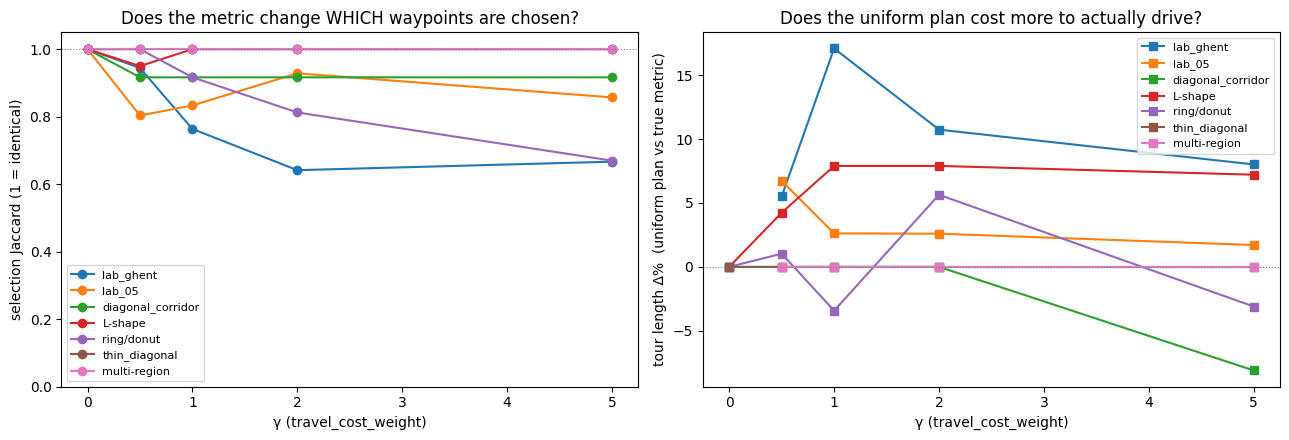

In [22]:
# Visual: how selection agreement and driven-cost penalty vary with γ, per map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for name in CASE_MAPS:
    js = [(_agg(name, g) or (np.nan,)*4)[0] for g in GAMMAS]
    ds = [(_agg(name, g) or (np.nan,)*4)[3] for g in GAMMAS]

    ax1.plot(GAMMAS, js, marker="o", label=name)
    ax2.plot(GAMMAS, ds, marker="s", label=name)
ax1.set_xlabel("γ (travel_cost_weight)"); ax1.set_ylabel("selection Jaccard (1 = identical)")
ax1.set_title("Does the metric change WHICH waypoints are chosen?"); ax1.set_ylim(0, 1.05)
ax1.axhline(1.0, color="gray", ls=":", lw=0.8); ax1.legend(fontsize=8)
ax2.set_xlabel("γ (travel_cost_weight)"); ax2.set_ylabel("tour length Δ%  (uniform plan vs true metric)")
ax2.set_title("Does the uniform plan cost more to actually drive?")
ax2.axhline(0.0, color="gray", ls=":", lw=0.8); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Conclusion — the uniform-BFS approximation is NOT negligible

Verdict from the exhaustive sweep (4 starts × γ ∈ {0,0.5,1,2,5} × 7 maps), scoring both plans
under the true (√2-weighted) metric. **Control check passes:** at γ=0 every map is Jaccard 1.0 /
first-wp 100% — the metric is unused, so the harness is sound.

At the production **γ = 1.0**:

| map | sel Jaccard | tour Δ% (uniform vs corrected) | reading |
|-----|------------:|-------------------------------:|---------|
| **lab_ghent** | 0.76 | **+17.1%** | uniform drives 17% farther; selection also differs |
| L-shape | 1.00 | +7.9% | same waypoints, worse **order** (τ↓) → ordering effect |
| lab_05 | 0.83 | +2.6% | mild |
| ring/donut | 0.92 | −3.4% | selection differs; greedy noise (sign flips across γ) |
| thin_diagonal | 1.00 | 0% | too few waypoints to reshuffle |
| multi-region | 1.00 | 0% | degenerate single-waypoint plans (see `ordered frac`) |

**Findings**

1. **It matters on the real maps.** lab_ghent's +17% driven-distance penalty at γ=1.0 is the
   headline: the uniform metric materially changes the plan for the worse.
2. **It acts through *both* selection and ordering.** lab_ghent shows a selection change
   (Jaccard 0.76); L-shape shows a pure *ordering* change (Jaccard 1.0 but +7.9% drive, τ↓).
   This is exactly why tour-Δ% is measured separately from Jaccard — Jaccard alone would have
   missed the L-shape effect.
3. **The effect needs diagonal geometry *and* enough waypoints.** thin_diagonal has maximal
   per-step bias but too few candidates to produce an alternative plan → 0%.
4. **It is noisy.** Downstream greedy set-cover + nearest-neighbour TSP are not monotonic in
   distance accuracy, so ring/donut even flips sign. +17% is evidence of material perturbation,
   not a guaranteed saving.

**Decision: worth fixing (deferred TODO).** Switch `bfs_distance_map` to a √2-weighted metric
(BFS → Dijkstra). Recorded in `docs/TODO_exploration_refactor.md` §1. Deferred because it changes
distances → waypoints/order → requires re-verifying `TestBfsDistanceMap` and ordering/integration
tests; out of scope for the safe-cleanup pass.

## Computational cost — is the √2 metric too slow to adopt?

A common objection to switching BFS → Dijkstra is "Dijkstra is slower." This checks it directly.
Two things are measured per map:

1. **standalone per-call time** of the current uniform `bfs_distance_map` vs the √2-weighted
   Dijkstra (scipy-`csgraph`, graph built once and cached);
2. **the distance computation as a fraction of a full `plan_waypoints` call** — because if
   planning time is dominated by the 360-ray `compute_all_visibility`, the metric's cost is
   irrelevant either way.

In [23]:
import timeit as _tt

def _first_nav(md):
    ys, xs = np.where(md.navigable_mask)
    return int(xs[0]), int(ys[0])  # (col, row)

# warm the Dijkstra graph cache so the build cost isn't counted in the per-call timing
for md in CASE_MAPS.values():
    sc, sr = _first_nav(md)
    dijkstra_weighted(md.navigable_mask, sc, sr)

print(f"{'map':<18}{'uniform BFS ms':>16}{'weighted Dijk ms':>18}{'full plan s':>14}"
      f"{'dist % of plan':>16}")
for name, md in CASE_MAPS.items():
    sc, sr = _first_nav(md)
    n = 5
    t_bfs = min(_tt.repeat(lambda: ecm.bfs_distance_map(md.navigable_mask, sc, sr),
                           repeat=3, number=n)) / n
    t_dij = min(_tt.repeat(lambda: dijkstra_weighted(md.navigable_mask, sc, sr),
                           repeat=3, number=n)) / n
    # one full plan (γ=1 so the distance map is actually computed inside)
    cfg = _cfg(1.0)
    rx, ry = STARTS[name][0]
    md.covered_mask[:] = False
    t_plan = min(_tt.repeat(lambda: _plan(md, cfg, rx, ry), repeat=1, number=1))
    frac = (t_dij / t_plan * 100.0) if t_plan else float("nan")
    print(f"{name:<18}{t_bfs*1e3:>16.3f}{t_dij*1e3:>18.3f}{t_plan:>14.2f}{frac:>15.2f}%")

print("\nNote: the weighted Dijkstra here is scipy-csgraph (C); the current bfs_distance_map is\n"
      "pure Python. A production √2 fix would likely be comparable to or faster than the current\n"
      "BFS. Either way, the 'dist % of plan' column is the deciding number: if it's tiny, the\n"
      "metric's cost is irrelevant next to compute_all_visibility (the 360-ray scans).")

map                 uniform BFS ms  weighted Dijk ms   full plan s  dist % of plan
lab_ghent                  254.684            17.498         10.45           0.17%
lab_05                       0.735             1.207          2.34           0.05%
diagonal_corridor            8.566             0.583          0.26           0.23%
L-shape                     72.299             3.455          1.62           0.21%
ring/donut                 109.930             6.909          2.44           0.28%
thin_diagonal               24.070             0.887          0.49           0.18%
multi-region                13.391             1.997          0.35           0.58%

Note: the weighted Dijkstra here is scipy-csgraph (C); the current bfs_distance_map is
pure Python. A production √2 fix would likely be comparable to or faster than the current
BFS. Either way, the 'dist % of plan' column is the deciding number: if it's tiny, the
metric's cost is irrelevant next to compute_all_visibility (the 360-ray